# Анализ авиарейсов и временных задержек

Описание датасета:
Датасет представлен файлом csv, в котором 336 776 строк и 13 столбцов, содержащих

`year`, `month`, `day`: дата вылета;

`dep_time`, `arr_time`: фактическое время отправления и прибытия (формат HHMM или HMM), местный часовой пояс;

`dep_delay`, `arr_delay`: задержки отправления и прибытия, в минутах. Отрицательное время означает ранние отправления/прибытия;

`carrier`: двухбуквенная аббревиатура перевозчика;

`flight`: номер рейса;

`tailnum`: бортовой номер самолета;

`origin`, `dest`: аэропорты отправления и назначения;

`air_time`: количество времени, проведенного в воздухе, в минутах;

`distance`: расстояние между аэропортами отправления и назначения.

Аббревиатуры аэропортов Нью-Йорка: 

`JFK` – John F. Kennedy International Airport; 

`LGA` – LaGuardia Airport; 

`EWR` – Newark International Airport.


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, ttest_ind
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('flights_NY.csv')
df = df.dropna()

df.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762


1. Выберите 10 аэропортов, в которые чаще всего летают из Нью-Йорка. Для каждого  из них оцените вероятность, что рейс прилетит с положительной задержкой (arr_delay > 0) и постройте график (столбчатая диаграмма), на котором по оси х – название аэропорта, по оси y – вероятность задержки прилета. Названия аэропортов по оси х расположите слева направо по убыванию количества рейсов в этот аэропорт. Для какого аэропорта из этих 10 вероятность окажется наибольшей, и для какого – наименьшей? 


In [3]:
top_dest_from_NY = df[(df['origin'] == 'JFK') | 
                (df['origin'] == 'LGA') | 
                (df['origin'] == 'EWR')].groupby('dest').agg(amount_of_flights = ('dest', 'count')).sort_values(by = 'amount_of_flights', ascending = False).head(10)
print(top_dest_from_NY)

      amount_of_flights
dest                   
ATL               16837
ORD               16566
LAX               16026
BOS               15022
MCO               13967
CLT               13674
SFO               13173
FLL               11897
MIA               11593
DCA                9111


In [4]:
df_merged = pd.merge(df, top_dest_from_NY, how = 'inner', on = 'dest')
positive_arr_delay = df_merged[df_merged['arr_delay'] > 0].groupby('dest').agg(num_of_pos_delays = ('dest', 'count')).sort_index()
total_flights = df_merged.groupby('dest').agg(num_of_flights = ('dest', 'count')).sort_index()
positive_arr_delay_share = positive_arr_delay['num_of_pos_delays'] / total_flights['num_of_flights']
print(positive_arr_delay_share)

dest
ATL    0.471937
BOS    0.315737
CLT    0.426942
DCA    0.439359
FLL    0.438094
LAX    0.372332
MCO    0.397007
MIA    0.332528
ORD    0.374140
SFO    0.375085
dtype: float64


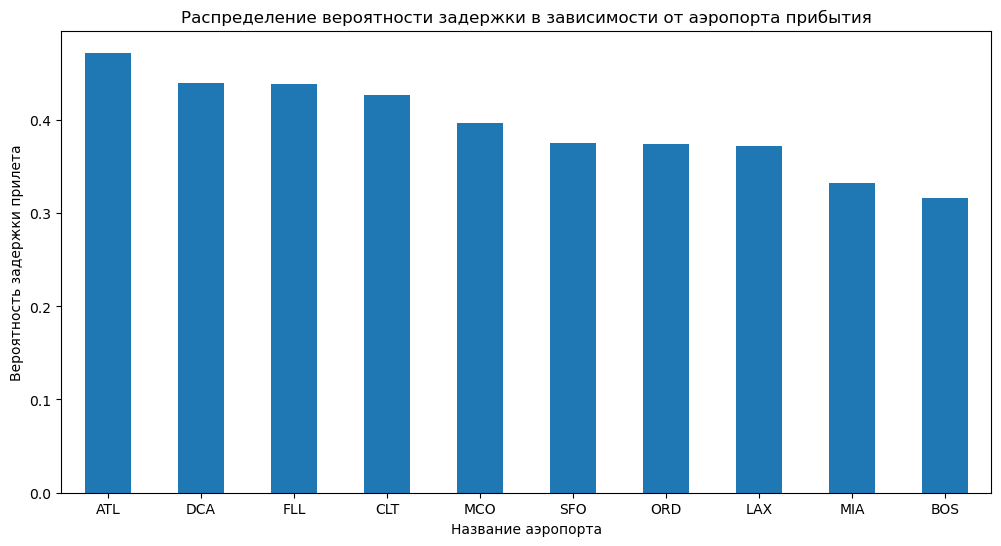

In [5]:
plt.figure(figsize = (12,6))
positive_arr_delay_share.sort_values(ascending = False).plot(kind = 'bar')
plt.xlabel('Название аэропорта')
plt.ylabel('Вероятность задержки прилета')
plt.xticks(rotation=0)
plt.title('Распределение вероятности задержки в зависимости от аэропорта прибытия')
plt.show()

2. Постройте нормированную гистограмму распределения времени перелета из Нью-Йорка в Сан-Франциско (SFO). Предполагая, что это распределение описывается нормальным законом, оцените параметры нормального закона и наложите график плотности полученного нормального закона на график с гистограммой. В каких пределах с вероятностью не менее 95% лежит время полета?


In [6]:
NY_to_SFO = df[(df['dest'] == 'SFO') & ((df['origin'] == 'JFK') | 
                (df['origin'] == 'LGA') | 
                (df['origin'] == 'EWR'))].copy()

In [7]:
mu = NY_to_SFO['air_time'].mean()
sigma = NY_to_SFO['air_time'].std()

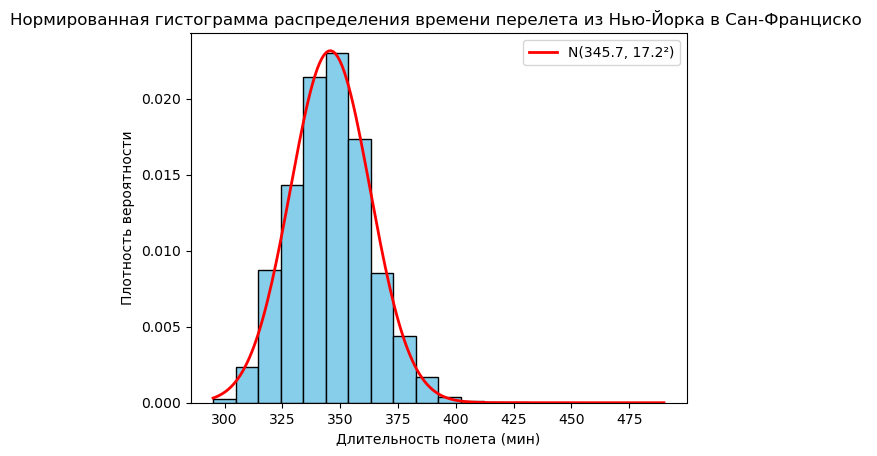

In [8]:
plt.hist(NY_to_SFO['air_time'], bins=20, edgecolor='black', color='skyblue', density=True)
plt.title('Нормированная гистограмма распределения времени перелета из Нью-Йорка в Сан-Франциско ')
plt.xlabel('Длительность полета (мин)')
plt.ylabel('Плотность вероятности')


x = np.linspace(NY_to_SFO['air_time'].min(), NY_to_SFO['air_time'].max(), 200)
pdf = norm.pdf(x, mu, sigma)
plt.plot(x, pdf, color='red', linewidth=2, label=f'N({mu:.1f}, {sigma:.1f}²)')
plt.legend()
plt.show()

Воспользуюсь правилом 2 сигма: Для нормального распределения ≈ 95% значений лежат в пределах μ ± 2σ (точнее: μ ± 1.96σ)

In [9]:
lower_bound = mu - 1.96 * sigma
upper_bound = mu + 1.96 * sigma

print(f"С 95% вероятностью длительность полёта лежит в пределах от {lower_bound:.1f} до {upper_bound:.1f} минут.")


С 95% вероятностью длительность полёта лежит в пределах от 311.9 до 379.5 минут.


3. Нарисуйте распределение по часам (0-23) количества вылетов из аэропорта JFK и найдите два пиковых часа (один до полудня, другой – после полудня) по количеству вылетов (время вылета переводите в час вылета округлением вниз, например 7:20 -> 7, 16:45 -> 16). Для каждого из двух найденных пиковых часов найдите среднее время задержки вылетов в этот час. Когда средняя задержка больше? Будет ли это различие в средних значениях статистически значимо?


In [10]:
dep_JFK = df[df['origin'] == 'JFK'].copy()
dep_JFK.loc[dep_JFK['dep_time'] > 2359, 'dep_time'] = 0

dep_JFK['dep_hour'] = dep_JFK['dep_time'] // 100
dep_JFK['dep_hour'] = dep_JFK['dep_hour'].astype(int)
distr_of_dep = dep_JFK.groupby('dep_hour').agg(amnt_of_flights = ('origin', 'count'))

distr_of_dep = distr_of_dep.reindex(range(24), fill_value=0)
distr_of_dep.head(24)


,amnt_of_flights
dep_hour,
0,619
1,136
2,47
3,11
4,0
5,1679
6,6269
7,7011
8,9946


<Figure size 1500x600 with 0 Axes>

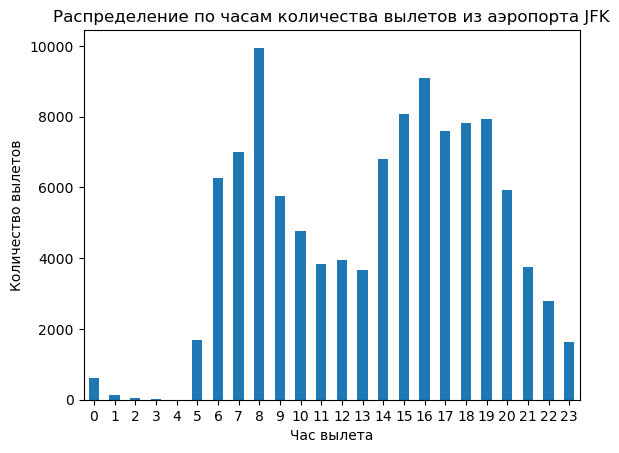

In [32]:
plt.figure(figsize=(15,6))
distr_of_dep.plot(kind = 'bar')
plt.title('Распределение по часам количества вылетов из аэропорта JFK')
plt.xlabel('Час вылета')
plt.ylabel('Количество вылетов')
plt.xticks(rotation=0)
plt.legend().remove()
plt.show()

Из распределения видно, что до 12:00 пиковый час - 08:00, после 12:00 больше всего вылетов в 16:00

In [12]:
dep_8am_JFK = dep_JFK[dep_JFK['dep_hour'] == 8]
mean_8am_delay = dep_8am_JFK['dep_delay'].mean()
print(f'Среднее время задержки из аэропорта JFK в 8 утра составляет {round(mean_8am_delay, 2)} минут')
dep_16pm_JFK = dep_JFK[dep_JFK['dep_hour'] == 16]
mean_16pm_delay = dep_16pm_JFK['dep_delay'].mean()
print(f'Среднее время задержки из аэропорта JFK в 16 дня составляет {round(mean_16pm_delay, 2)} минут')

Среднее время задержки из аэропорта JFK в 8 утра составляет 1.04 минут
Среднее время задержки из аэропорта JFK в 16 дня составляет 10.87 минут


In [13]:
t_stat, p_value = ttest_ind(dep_8am_JFK['dep_delay'],dep_16pm_JFK['dep_delay'], alternative = 'greater', equal_var=False )

alpha = 0.05

if p_value < alpha:
    print(f'p-value равен {p_value}. Разница статистически значима, вылеты действительно сильнее задерживаются в 16:00')
else:
    print(f'p-value равен {p_value}. Разница не является статистически значимой, вылеты в 16:00 и 08:00 задерживаются одинаково')
    
          

p-value равен 1.0. Разница не является статистически значимой, вылеты в 16:00 и 08:00 задерживаются одинаково


4. Для каждого аэропорта прилета найдите величину стандартного отклонения времени перелета. Постройте график (точечная диаграмма) зависимости стандартного отклонения от расстояния до аэропорта. Аппроксимируйте полученную зависимость моделью линейной регрессии на основе расстояния до аэропорта  Добавьте к предыдущему графику график линейной регрессии. Уточните модель линейной регрессии, используя дополнительные входные признаки на основе расстояния до аэропорта. Добавьте график уточненной модели. Сравните точность моделей.


In [14]:
df_std_air_time = df.groupby('dest').agg(std_air_time = ('air_time','std')).reset_index()
df_std_air_time.head()

,dest,std_air_time
0,ABQ,19.291371
1,ACK,8.127495
2,ALB,3.084754
3,ANC,14.672009
4,ATL,9.812387


In [15]:
dest_distance_pairs = df[['dest', 'distance']].drop_duplicates()
dest_distance_pairs_merged = pd.merge(dest_distance_pairs, df_std_air_time, how = 'left', on = 'dest')
dest_distance_pairs_merged = dest_distance_pairs_merged.dropna()


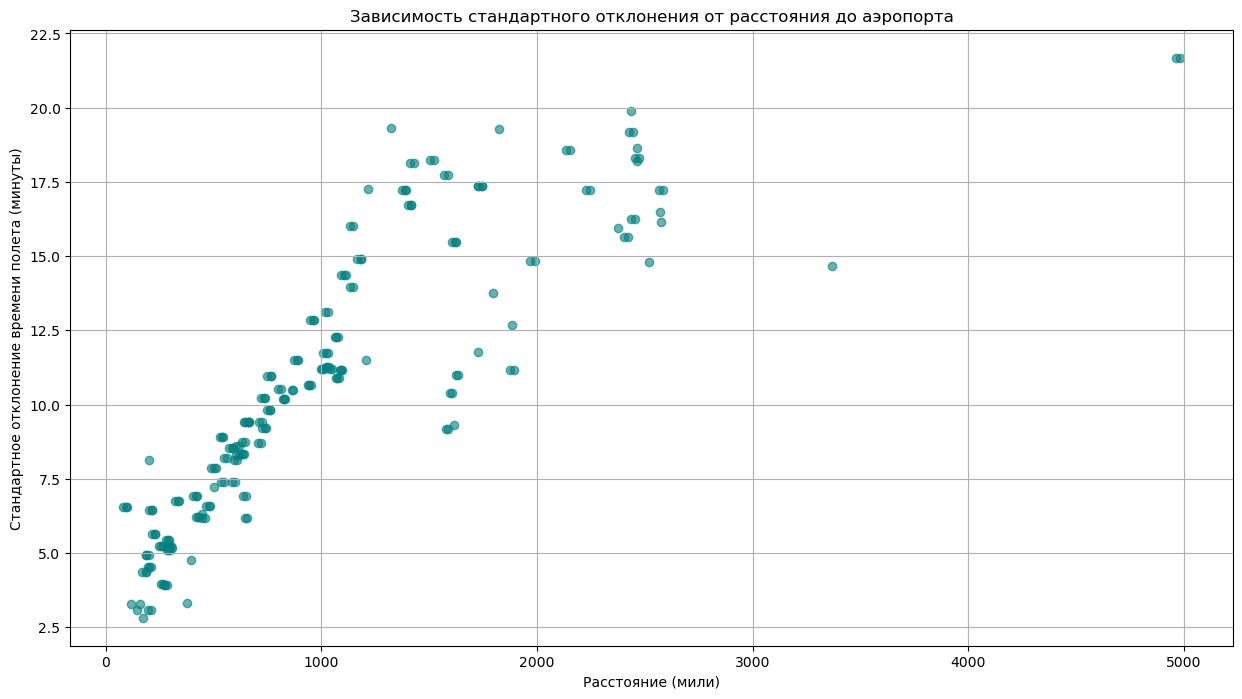

In [16]:
x = dest_distance_pairs_merged['distance']
y = dest_distance_pairs_merged['std_air_time']

plt.figure(figsize=(15, 8))
plt.scatter(x, y, alpha=0.6, color='teal')
plt.title('Зависимость стандартного отклонения от расстояния до аэропорта')
plt.xlabel('Расстояние (мили)')
plt.ylabel('Стандартное отклонение времени полета (минуты)')
plt.grid(True)
plt.show()

Видно, что есть выбросы в области больших расстояний. Уберу их для более точной аппроксимации

In [23]:
X = dest_distance_pairs_merged[dest_distance_pairs_merged['distance'] < 3370]['distance'].values.reshape(-1, 1) 
Y = dest_distance_pairs_merged[dest_distance_pairs_merged['distance'] < 3370]['std_air_time'].values             


model = LinearRegression()
model.fit(X, Y)
Y_pred1 = model.predict(X)

x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)

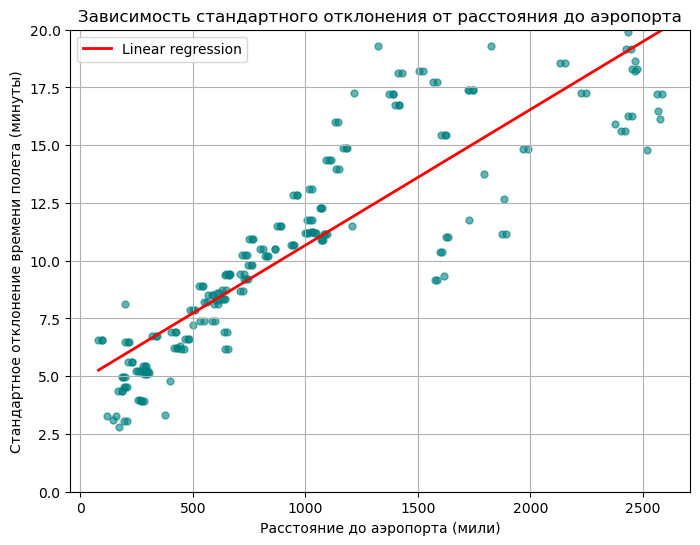

In [24]:
plt.figure(figsize=(8, 6))


x = dest_distance_pairs_merged[dest_distance_pairs_merged['distance'] < 3370]['distance']
y = dest_distance_pairs_merged[dest_distance_pairs_merged['distance'] < 3370]['std_air_time']
plt.scatter(x, y, alpha=0.6, color='teal', s = 25)


plt.plot(x_line, y_line, color='red', linewidth=2, label='Linear regression')


plt.title('Зависимость стандартного отклонения от расстояния до аэропорта')
plt.xlabel('Расстояние до аэропорта (мили)')
plt.ylabel('Стандартное отклонение времени полета (минуты)')
plt.ylim(0, 20)
plt.legend()
plt.grid(True)
plt.show()


Уточню модель, используя дополнительные входные признаки на основе расстояния до аэропорта. Возьму квадрат расстояния и логарифм расстояния.

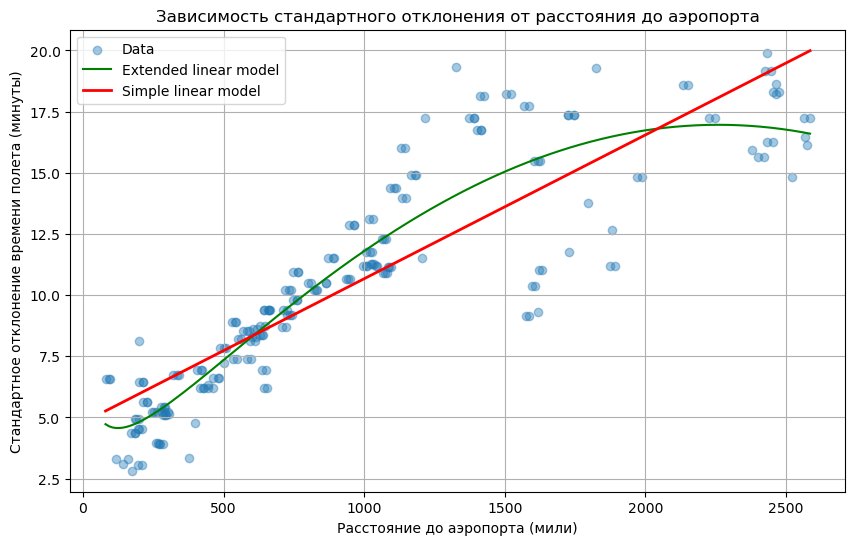

In [31]:
X_square = X ** 2
X_log = np.log(X)

X_combined = np.hstack([X, X_square, X_log])
model2 = LinearRegression()
model2.fit(X_combined, Y)

Y_pred2 = model2.predict(X_combined)

x_line2 = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
x_square2 = x_line2 ** 2
x_log2 = np.log(x_line2)
x_line2_combined = np.hstack([x_line2, x_square2, x_log2])

y_line2 = model2.predict(x_line2_combined)


plt.figure(figsize=(10, 6))
#точки
plt.scatter(x, y, alpha=0.4, label='Data')
#новая модель
plt.plot(x_line2, y_line2, color='green', label='Extended linear model')
#старая модель
plt.plot(x_line, y_line, color='red', linewidth=2, label='Simple linear model')

plt.xlabel('Расстояние до аэропорта (мили)')
plt.ylabel('Стандартное отклонение времени полета (минуты)')
plt.title('Зависимость стандартного отклонения от расстояния до аэропорта')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
print("Простая модель:")
print("  MSE:", mean_squared_error(Y, Y_pred1))
print("  MAE:", mean_absolute_error(Y, Y_pred1))
print("  R² :", r2_score(Y, Y_pred1))

print("Уточнённая модель:")
print("  MSE:", mean_squared_error(Y, Y_pred2))
print("  MAE:", mean_absolute_error(Y, Y_pred2))
print("  R² :", r2_score(Y, Y_pred2))

Простая модель:
  MSE: 4.534503869930848
  MAE: 1.6039058565157116
  R² : 0.7708818178893249
Уточнённая модель:
  MSE: 3.1680650469952667
  MAE: 1.2352914058177402
  R² : 0.8399248682553234


5. Методом кластерного анализа выделите три группы авиакомпаний на основе пары признаков: средняя задержка прилета и средняя задержка вылета. Постройте точечную диаграмму на этих признаках и раскрасьте точки в соответствии с номером кластера. Попробуйте дать интерпретацию кластерам (в этом может помочь название авиакомпании).


In [58]:
grouped_carrier = df.groupby('carrier').agg(
    mean_dep_delay=('dep_delay', 'mean'),
    mean_arr_delay=('arr_delay', 'mean')
).dropna()


In [60]:
X = grouped_carrier[['mean_dep_delay', 'mean_arr_delay']].values


kmeans = KMeans(n_clusters=3, random_state=42)
grouped_carrier['cluster'] = kmeans.fit_predict(X)


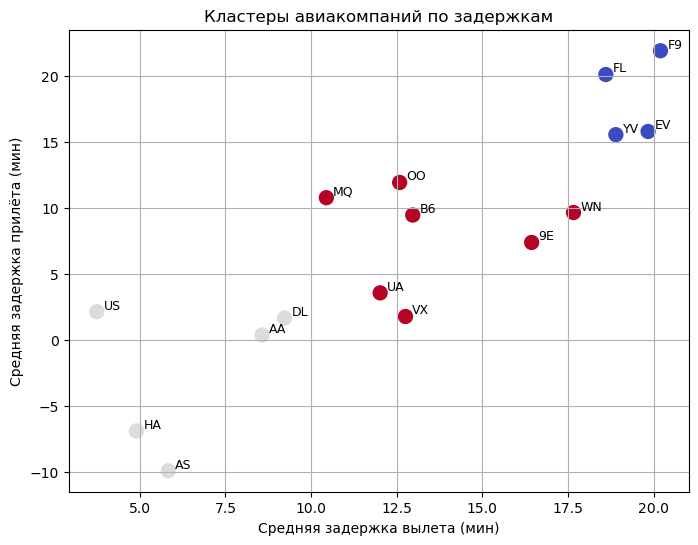

In [61]:
plt.figure(figsize=(8, 6))
plt.scatter(grouped_carrier['mean_dep_delay'], grouped_carrier['mean_arr_delay'],
            c=grouped_carrier['cluster'], cmap='coolwarm', s=100)


for carrier, row in grouped_carrier.iterrows():
    plt.text(row['mean_dep_delay'] + 0.2, row['mean_arr_delay'] + 0.2, carrier, fontsize=9)

plt.xlabel('Средняя задержка вылета (мин)')
plt.ylabel('Средняя задержка прилёта (мин)')
plt.title('Кластеры авиакомпаний по задержкам')
plt.grid(True)
plt.show()


Кластер 1: US, HA, AS, AA, DL (Кластер стабильных крупных перевозчиков)
Имеют разветвлённую инфраструктуру, могут справляться с логистикой сложных маршрутов -> меньше всего задержек

Кластер 2: MQ, OO, B6, UA, VX (Региональные перевозчики)
Кластер смешанного типа с высокой нагрузкой, региональные рейсы имеют большую плотность и часто страдают от накопленных задержек

Кластер 3: F9, FL, YV, EV (Низкобюджетные авиакомпании, региональные перевозчики)
Кластер с повышенными задержками. LCC (Low-Cost Carrier) часто страдают от задержек из-за меньших временных буферов и высокой загруженности самолётов.


